In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import librosa as lb
import soundfile as sf
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report
from tensorflow.keras import layers, models, activations
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from joblib import Parallel, delayed

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from smart_stethoscope.interface import main
X_train, X_val, X_test, y_train, y_val, y_test, train_cycle_filenames, val_cycle_filenames, test_cycle_filenames = main.preprocessing()


✅ Processed audio files already exist, skipping extraction

Load data from cached CSV...


/Users/miameyer/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/miameyer/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [5]:
def load_audio(file_path):
    audio, _ = lb.load(file_path, sr=None)
    return audio

def get_audio_data(cycle_filenames):
    folder = Path('../preprocessed_data/padded_audio_breathing_cycles')

    file_paths = [folder / f"{fname}.wav" for fname in cycle_filenames]

    audios = Parallel(n_jobs=-1)(
        delayed(load_audio)(fp) for fp in file_paths
    )

    return np.stack(audios).astype(np.float32)

In [6]:
audio_train_array = get_audio_data(train_cycle_filenames)
audio_val_array = get_audio_data(val_cycle_filenames)
audio_test_array = get_audio_data(test_cycle_filenames)

In [11]:
def compute_mfcc_with_deltas(audio, sr=22050, n_mfcc=40):
    # MFCC
    mfcc = lb.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=n_mfcc
    )

    # First derivative
    delta = lb.feature.delta(mfcc)

    # Second derivative
    delta2 = lb.feature.delta(mfcc, order=2)

    # Stack as channels
    mfcc_combined = np.stack([mfcc, delta, delta2], axis=-1)

    return mfcc_combined

In [12]:
def get_mfcc(audio_array):
    mels = Parallel(n_jobs=-1)(
        delayed(compute_mfcc_with_deltas)(audio) for audio in audio_array
    )

    return np.stack(mels)

In [13]:
X_train_img = get_mfcc(audio_train_array)
X_val_img = get_mfcc(audio_val_array)
X_test_img = get_mfcc(audio_test_array)

In [ ]:
num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
input_shape = X_train_img.shape[1:]

In [13]:
# Convert one-hot back to integer labels
y_train_int = np.argmax(y_train_cat, axis=1)

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weights_dict = dict(enumerate(class_weights))

In [41]:
mSpec_input=layers.Input(shape=input_shape,name="mSpecInput")
x=layers.Conv2D(32,3,strides=(2,3),padding='same')(mSpec_input)
x=layers.BatchNormalization()(x)
x=layers.Activation(activations.relu)(x)
x=layers.MaxPooling2D(pool_size=2,padding='valid')(x)

x=layers.Conv2D(64,3,strides=(2,2),padding='same')(x)
x=layers.BatchNormalization()(x)
x=layers.Activation(activations.relu)(x)
#x=layers.MaxPooling2D(pool_size=2,padding='valid')(x)
x=layers.GlobalMaxPooling2D()(x)

#x=layers.Conv2D(128,2,padding='same')(x)
#x=layers.BatchNormalization()(x)
#x=layers.Activation(activations.relu)(x)
#x=layers.GlobalMaxPooling2D()(x)

x = layers.Dense(32, activations.relu)(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(16, activations.relu)(x)
x = layers.Dropout(0.3)(x)
mSpec_output = layers.Dense(num_classes, activations.softmax)(x)

mSpec_model=tf.keras.Model(mSpec_input, mSpec_output, name="mSpecModel")

In [42]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=5e-4)
mSpec_model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20, # instead of 3
    restore_best_weights=True
)
my_callbacks = [
    early_stopping,
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                                         patience=3, min_lr=0.00001,mode='min')
]

history = mSpec_model.fit(
    X_train_img,
    y_train_cat,
    validation_data=(X_val_img, y_val_cat),
    epochs=200,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[my_callbacks],
    verbose=1
)

test_loss, test_accuracy = mSpec_model.evaluate(X_test_img, y_test_cat, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Epoch 1/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0536 - loss: 2.1811 - val_accuracy: 0.0360 - val_loss: 1.8662 - learning_rate: 5.0000e-04
Epoch 2/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1008 - loss: 1.8109 - val_accuracy: 0.4100 - val_loss: 1.7642 - learning_rate: 5.0000e-04
Epoch 3/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1489 - loss: 1.7847 - val_accuracy: 0.6260 - val_loss: 1.7438 - learning_rate: 5.0000e-04
Epoch 4/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1847 - loss: 1.7721 - val_accuracy: 0.6118 - val_loss: 1.7551 - learning_rate: 5.0000e-04
Epoch 5/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3252 - loss: 1.7686 - val_accuracy: 0.6369 - val_loss: 1.7236 - learning_rate: 5.0000e-04
Epoch 6/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4017 - loss: 1.7398 - val_accuracy: 0.6216 - val_loss: 1.7205 - learning_rate: 5.0000e-04
Epoch 7/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - a

In [44]:
# Predict and evaluate
y_pred_probs = mSpec_model.predict(X_test_img)

y_pred_cnn = np.argmax(y_pred_probs, axis=1)
y_test_int = np.argmax(y_test_cat, axis=1)

print(classification_report(y_test_int, y_pred_cnn, zero_division=0))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.19      0.07      0.10        57
           1       0.99      0.81      0.89       891
           2       0.23      0.51      0.32        43
           3       0.30      0.29      0.30        24
           4       0.14      0.85      0.24        26
           5       0.14      0.38      0.20        13

    accuracy                           0.74      1054
   macro avg       0.33      0.49      0.34      1054
weighted avg       0.87      0.74      0.79      1054



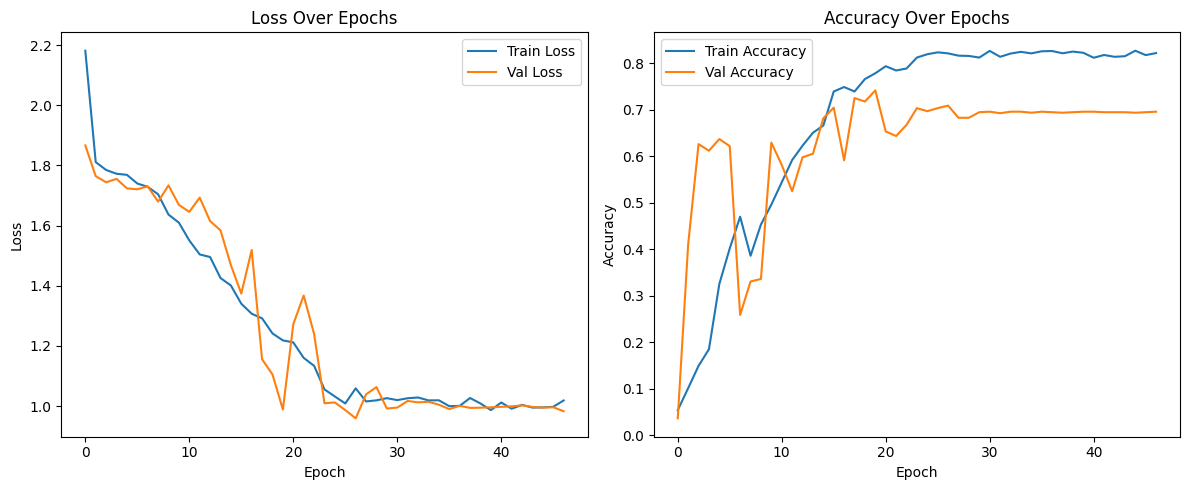

In [45]:
# Plot training vs validation curves

history_dict = history.history

# Loss plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# RNN Model

In [67]:
def extract_features(audio):
    mfcc = lb.feature.mfcc(y=audio, sr=22050, n_mfcc=40)
    delta = lb.feature.delta(mfcc)
    mfcc = mfcc.T
    delta = delta.T
    spec_centroid = lb.feature.spectral_centroid(y=audio, sr=22050)
    spec_bandwidth = lb.feature.spectral_bandwidth(y=audio, sr=22050)
    spec_rolloff = lb.feature.spectral_rolloff(y=audio, sr=22050)
    zcr = lb.feature.zero_crossing_rate(audio)

    spec = np.vstack([
        spec_centroid,
        spec_bandwidth,
        spec_rolloff,
        zcr
    ]).T

    return mfcc, delta, spec

In [68]:
def get_features(audio_array):
    results = Parallel(n_jobs=-1)(
        delayed(extract_features)(audio) for audio in audio_array
    )
    mfcc, delta, spec = zip(*results)
    mfcc = np.stack(mfcc).astype(np.float32)
    delta = np.stack(delta).astype(np.float32)
    spec = np.stack(spec).astype(np.float32)

    return mfcc, delta, spec

In [69]:
X_train_mfcc, X_train_delta, X_train_spec = get_features(audio_train_array)
X_val_mfcc, X_val_delta, X_val_spec = get_features(audio_val_array)
X_test_mfcc, X_test_delta, X_test_spec = get_features(audio_test_array)

In [89]:
def compute_normalization_stats(X):
    # X shape: (N, T, F)
    mean = np.mean(X, axis=(0, 1), keepdims=True)   # shape (1, 1, F)
    std = np.std(X, axis=(0, 1), keepdims=True) + 1e-6
    return mean, std

In [90]:
def normalize_features(X, mean, std):
    return (X - mean) / std

In [92]:
mfcc_mean, mfcc_std = compute_normalization_stats(X_train_mfcc)

X_train_mfcc = normalize_features(X_train_mfcc, mfcc_mean, mfcc_std)
X_val_mfcc   = normalize_features(X_val_mfcc, mfcc_mean, mfcc_std)
X_test_mfcc  = normalize_features(X_test_mfcc, mfcc_mean, mfcc_std)

# Delta
delta_mean, delta_std = compute_normalization_stats(X_train_delta)

X_train_delta = normalize_features(X_train_delta, delta_mean, delta_std)
X_val_delta   = normalize_features(X_val_delta, delta_mean, delta_std)
X_test_delta  = normalize_features(X_test_delta, delta_mean, delta_std)


# Spectral
spec_mean, spec_std = compute_normalization_stats(X_train_spec)

X_train_spec = normalize_features(X_train_spec, spec_mean, spec_std)
X_val_spec   = normalize_features(X_val_spec, spec_mean, spec_std)
X_test_spec  = normalize_features(X_test_spec, spec_mean, spec_std)

In [93]:
num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)

In [94]:
# Convert one-hot back to integer labels
y_train_int = np.argmax(y_train_cat, axis=1)

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weights_dict = dict(enumerate(class_weights))

In [95]:
input_mfcc = layers.Input(shape=(None, 40), name='mfcc')
input_delta = layers.Input(shape=(None, 40), name='delta')
input_spec = layers.Input(shape=(None, 4), name='spec')

# MFCC branch
x1 = layers.Masking()(input_mfcc)
x1 = layers.LSTM(64)(x1)

# Delta branch
x2 = layers.Masking()(input_delta)
x2 = layers.LSTM(64)(x2)

# Spectral branch
x3 = layers.Masking()(input_spec)
x3 = layers.LSTM(32)(x3)

# Fusion
concat = layers.concatenate([x1, x2, x3])

x = layers.Dense(64, activation='relu')(concat)
x = layers.Dropout(0.3)(x)
output = layers.Dense(6, activation='softmax')(x)

model = tf.keras.Model(
    [input_mfcc, input_delta, input_spec],
    output
)

In [96]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=5e-4)
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [97]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20, # instead of 3
    restore_best_weights=True
)
my_callbacks = [
    early_stopping,
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                                         patience=3, min_lr=0.00001,mode='min')
]

history=model.fit(
    {"mfcc":X_train_mfcc,"delta":X_train_delta,"spec":X_train_spec},
    y_train_cat,
    validation_data=({"mfcc":X_val_mfcc,"delta":X_val_delta,"spec":X_val_spec}, y_val_cat),
    epochs=200,
    verbose=1,
    class_weight=class_weights_dict,
    callbacks=my_callbacks
)

test_loss, test_accuracy = model.evaluate({"mfcc":X_test_mfcc,"delta":X_test_delta,"spec":X_test_spec}, y_test_cat, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Epoch 1/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.2254 - loss: 1.7971 - val_accuracy: 0.0207 - val_loss: 1.8243 - learning_rate: 5.0000e-04
Epoch 2/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - accuracy: 0.3136 - loss: 1.7604 - val_accuracy: 0.8146 - val_loss: 1.3332 - learning_rate: 5.0000e-04
Epoch 3/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - accuracy: 0.4524 - loss: 1.7192 - val_accuracy: 0.7797 - val_loss: 1.6893 - learning_rate: 5.0000e-04
Epoch 4/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - accuracy: 0.2401 - loss: 1.7737 - val_accuracy: 0.8146 - val_loss: 1.7287 - learning_rate: 5.0000e-04
Epoch 5/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.3712 - loss: 1.7629 - val_accuracy: 0.8397 - val_loss: 1.6419 - learning_rate: 5.0000e-04
Epoch 6/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.6234 - loss: 1.7280 - val_accuracy: 0.7819 - val_loss: 1.6148 - learning_rate: 5.0000e-05
Epoch 7/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 

In [98]:
# Predict and evaluate
y_pred_probs = model.predict({"mfcc":X_test_mfcc,"delta":X_test_delta,"spec":X_test_spec})

y_pred_cnn = np.argmax(y_pred_probs, axis=1)
y_test_int = np.argmax(y_test_cat, axis=1)

print(classification_report(y_test_int, y_pred_cnn, zero_division=0))

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
              precision    recall  f1-score   support

           0       0.12      0.02      0.03        57
           1       0.89      0.85      0.87       891
           2       0.00      0.00      0.00        43
           3       0.12      1.00      0.22        24
           4       0.00      0.00      0.00        26
           5       0.00      0.00      0.00        13

    accuracy                           0.74      1054
   macro avg       0.19      0.31      0.19      1054
weighted avg       0.76      0.74      0.74      1054



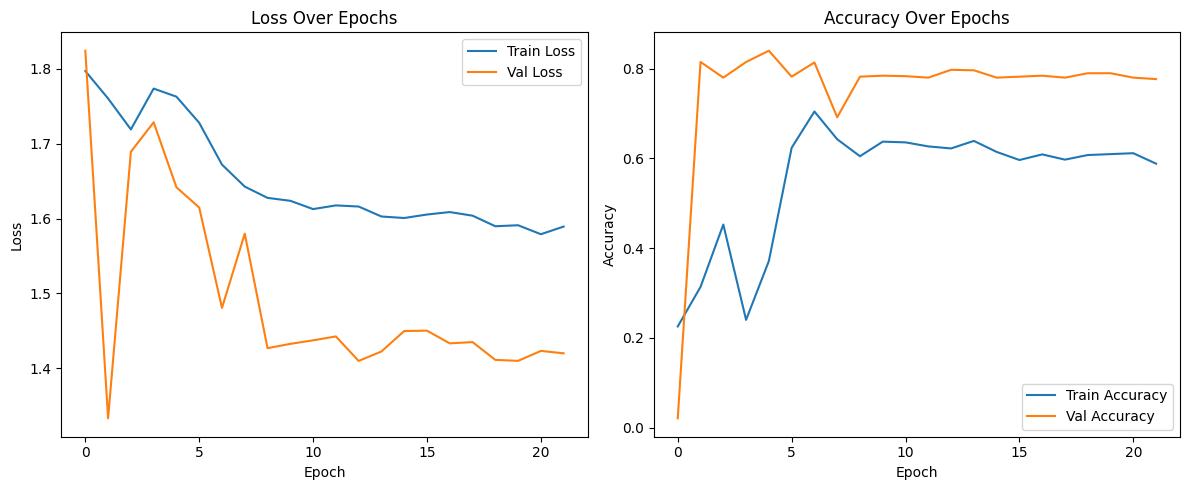

In [99]:
# Plot training vs validation curves

history_dict = history.history

# Loss plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [100]:
def extract_features_combined(audio, sr=22050):
    # MFCC
    mfcc = lb.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    # Delta
    delta = lb.feature.delta(mfcc)

    # Spectral features
    spec_centroid = lb.feature.spectral_centroid(y=audio, sr=sr)
    spec_bandwidth = lb.feature.spectral_bandwidth(y=audio, sr=sr)
    zcr = lb.feature.zero_crossing_rate(audio)

    # Stack features along feature axis
    features = np.vstack([
        mfcc,
        delta,
        spec_centroid,
        spec_bandwidth,
        zcr
    ])  # shape: (feature_dim, time)

    # transpose → (time, features)
    features = features.T

    return features

In [ ]:
def get_features_all(audio_array):
    features = Parallel(n_jobs=-1)(
        delayed(extract_features_combined)(audio) for audio in audio_array
    )

    #mfcc, delta, spec = zip(*results)
    #mfcc = np.stack(mfcc).astype(np.float32)
    #delta = np.stack(delta).astype(np.float32)
    #spec = np.stack(spec).astype(np.float32)

    return features

In [102]:
X_train= get_features_all(audio_train_array)
X_val = get_features_all(audio_val_array)
X_test = get_features_all(audio_test_array)

In [106]:
X_train = np.stack(X_train).astype(np.float32)
X_val   = np.stack(X_val).astype(np.float32)
X_test  = np.stack(X_test).astype(np.float32)

In [109]:
mean, std = compute_normalization_stats(X_train)

X_train = normalize_features(X_train, mean, std)
X_val   = normalize_features(X_val, mean, std)
X_test  = normalize_features(X_test, mean, std)

In [111]:
input_seq = layers.Input(shape=(None, X_train.shape[2]))

x = layers.Masking(mask_value=0.0)(input_seq)

x = layers.LSTM(64, return_sequences=True)(x)
x = layers.Dropout(0.3)(x)

x = layers.LSTM(32)(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(6, activation='softmax')(x)

model_rnn = tf.keras.Model(input_seq, output)

In [113]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=5e-4)
model_rnn.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [115]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20, # instead of 3
    restore_best_weights=True
)
my_callbacks = [
    early_stopping,
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                                         patience=3, min_lr=0.00001,mode='min')
]

history=model_rnn.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=200,
    verbose=1,
    class_weight=class_weights_dict,
    callbacks=my_callbacks
)

test_loss, test_accuracy = model_rnn.evaluate(X_test, y_test_cat, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Epoch 1/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.0636 - loss: 1.8036 - val_accuracy: 0.0338 - val_loss: 1.7426 - learning_rate: 5.0000e-04
Epoch 2/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - accuracy: 0.1285 - loss: 1.7879 - val_accuracy: 0.0207 - val_loss: 1.7903 - learning_rate: 5.0000e-04
Epoch 3/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.1442 - loss: 1.7901 - val_accuracy: 0.0360 - val_loss: 1.7572 - learning_rate: 5.0000e-04
Epoch 4/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.2614 - loss: 1.7731 - val_accuracy: 0.3370 - val_loss: 1.7389 - learning_rate: 5.0000e-04
Epoch 5/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.1612 - loss: 1.7755 - val_accuracy: 0.0207 - val_loss: 1.8340 - learning_rate: 5.0000e-04
Epoch 6/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.1982 - loss: 1.7731 - val_accuracy: 0.4951 - val_loss: 1.7055 - learning_rate: 5.0000e-04
Epoch 7/200
153/153 ━━━━━━━━━━━━━━━━━━━━

In [116]:
# Predict and evaluate
y_pred_probs = model_rnn.predict(X_test)

y_pred_cnn = np.argmax(y_pred_probs, axis=1)
y_test_int = np.argmax(y_test_cat, axis=1)

print(classification_report(y_test_int, y_pred_cnn, zero_division=0))

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        57
           1       0.94      0.68      0.79       891
           2       0.11      0.30      0.16        43
           3       0.19      0.75      0.30        24
           4       0.05      0.23      0.08        26
           5       0.00      0.00      0.00        13

    accuracy                           0.61      1054
   macro avg       0.21      0.33      0.22      1054
weighted avg       0.80      0.61      0.68      1054



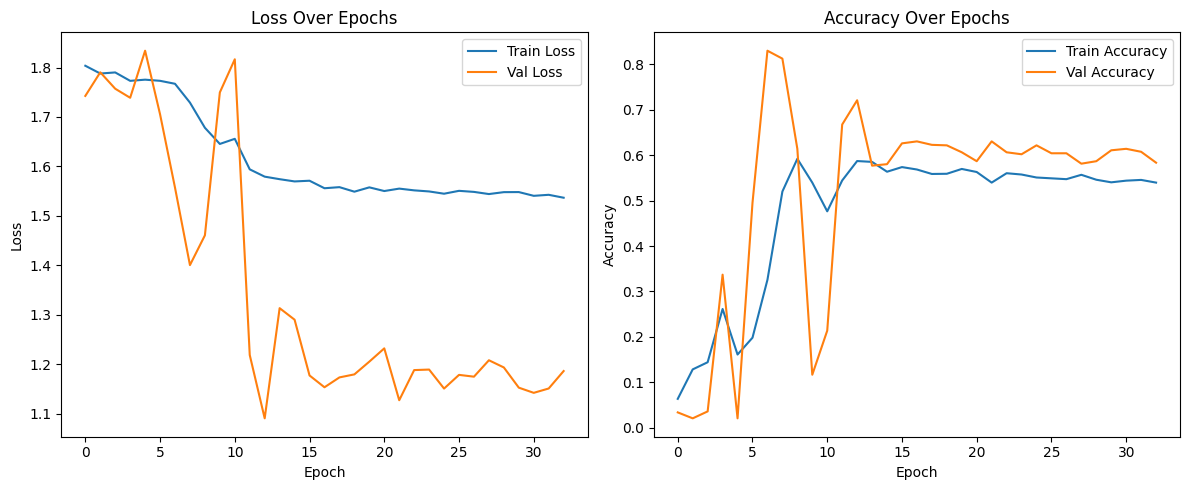

In [117]:
# Plot training vs validation curves

history_dict = history.history

# Loss plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# 1D CNN

In [8]:
X_train= audio_train_array
X_val = audio_val_array
X_test = audio_test_array

In [17]:
model_cnn_1d = tf.keras.Sequential([
    layers.Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(X_train.shape[1], 1)),
    layers.MaxPooling1D(pool_size=5, strides = 2, padding = 'same'),
    layers.Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'),
    layers.MaxPooling1D(pool_size=5, strides = 2, padding = 'same'),
    layers.Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'),
    layers.MaxPooling1D(pool_size=5, strides = 2, padding = 'same'),
    layers.Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'),
    layers.MaxPooling1D(pool_size=5, strides = 2, padding = 'same'),
    layers.Conv1D(32, kernel_size=5, strides=1, padding='same', activation='relu'),
    layers.MaxPooling1D(pool_size=5, strides = 2, padding = 'same'),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(units=32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(units=num_classes, activation='softmax')
])

/Users/miameyer/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=5e-4)
model_cnn_1d.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [124]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20, # instead of 3
    restore_best_weights=True
)
my_callbacks = [
    early_stopping,
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                                         patience=3, min_lr=0.00001,mode='min')
]

history=model_cnn_1d.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=200,
    verbose=1,
    class_weight=class_weights_dict,
    callbacks=my_callbacks
)

test_loss, test_accuracy = model_cnn_1d.evaluate(X_test, y_test_cat, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Epoch 1/200
110/153 ━━━━━━━━━━━━━━━━━━━━ 19:13 27s/step - accuracy: 0.4530 - loss: 1.7893

KeyboardInterrupt: 

In [9]:
def build_small_cnn(input_length):
    inputs = layers.Input(shape=(input_length, 1))

    # Block 1
    x = layers.Conv1D(16, kernel_size=9, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Block 2
    x = layers.Conv1D(32, kernel_size=5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Block 3
    x = layers.Conv1D(64, kernel_size=3, padding='same')(x)
    x = layers.ReLU()(x)

    # Global pooling instead of flatten (important!)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(6, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)


model_2 = build_small_cnn(input_length=X_train.shape[1])


In [10]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=5e-4)
model_2.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20, # instead of 3
    restore_best_weights=True
)
my_callbacks = [
    early_stopping,
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                                         patience=3, min_lr=0.00001,mode='min')
]

history=model_2.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=200,
    verbose=1,
    class_weight=class_weights_dict,
    callbacks=my_callbacks
)

test_loss, test_accuracy = model_2.evaluate(X_test, y_test_cat, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Epoch 1/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 46s 291ms/step - accuracy: 0.5913 - loss: 1.6687 - val_accuracy: 0.0109 - val_loss: 2.2689 - learning_rate: 5.0000e-04
Epoch 2/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 43s 280ms/step - accuracy: 0.5609 - loss: 1.5496 - val_accuracy: 0.0131 - val_loss: 2.6279 - learning_rate: 5.0000e-04
Epoch 3/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 43s 282ms/step - accuracy: 0.5631 - loss: 1.4921 - val_accuracy: 0.0120 - val_loss: 2.9739 - learning_rate: 5.0000e-04
Epoch 4/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 43s 278ms/step - accuracy: 0.5555 - loss: 1.4462 - val_accuracy: 0.0207 - val_loss: 2.3776 - learning_rate: 5.0000e-04
Epoch 5/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 43s 278ms/step - accuracy: 0.5598 - loss: 1.3909 - val_accuracy: 0.2007 - val_loss: 1.7768 - learning_rate: 5.0000e-05
Epoch 6/200
153/153 ━━━━━━━━━━━━━━━━━━━━ 43s 280ms/step - accuracy: 0.5680 - loss: 1.3719 - val_accuracy: 0.3490 - val_loss: 1.4908 - learning_rate: 5.0000e-05
Epoch 7/200
153/153 ━━━━━━━━━━━━━━━━━━━━

In [15]:
# Predict and evaluate
y_pred_probs = model_2.predict(X_test)

y_pred_cnn = np.argmax(y_pred_probs, axis=1)
y_test_int = np.argmax(y_test_cat, axis=1)

print(classification_report(y_test_int, y_pred_cnn, zero_division=0))

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
              precision    recall  f1-score   support

           0       0.10      0.19      0.13        57
           1       0.97      0.58      0.73       891
           2       0.16      0.47      0.24        43
           3       0.25      0.96      0.40        24
           4       0.09      0.31      0.14        26
           5       0.02      0.15      0.03        13

    accuracy                           0.55      1054
   macro avg       0.27      0.44      0.28      1054
weighted avg       0.84      0.55      0.64      1054



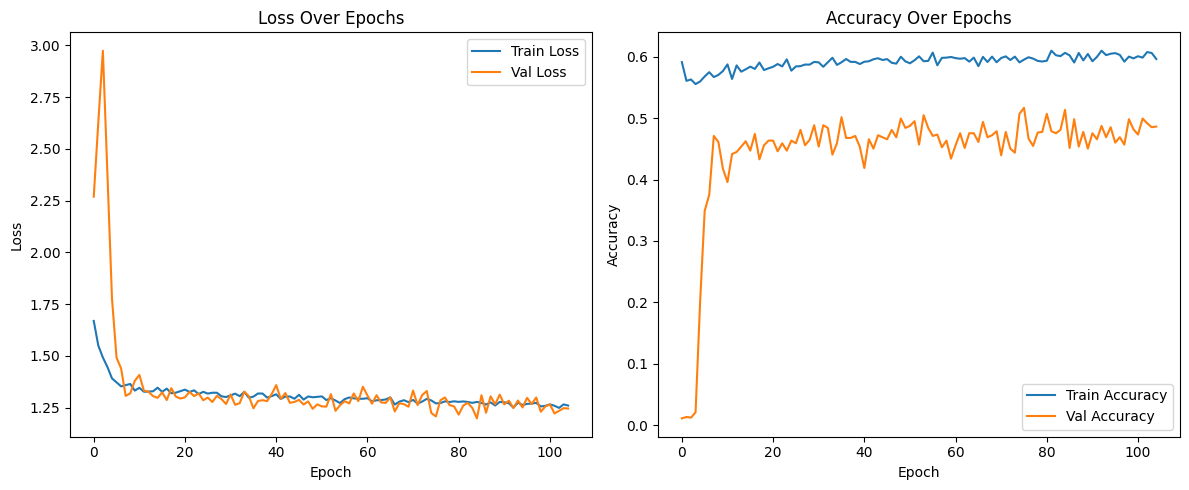

In [16]:
# Plot training vs validation curves

history_dict = history.history

# Loss plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()